STEP 1 — Create a notebook cell to load DB credentials & connect

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from scipy.stats import linregress

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")
DB_TABLE = os.getenv("DB_TABLE")

print("Loaded from .env:", DB_HOST, DB_USER, DB_NAME)

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

Loaded from .env: shtm-fallprev.mysql.database.azure.com ahistudent sbu_athletics


In [2]:
selected_metrics = [
    "accel_load_accum", 
    "distance_total",
    "Jump Height(m)", 
    "Peak Propulsive Force(N)", 
    "RSI"
]

metrics_str = ", ".join([f"'{m}'" for m in selected_metrics])

In [3]:
from sqlalchemy import text

# We want ONLY Men's Basketball, NOT Women's
mbb_pattern = "%Men's Basketball%"
wbb_pattern = "%Women's Basketball%"

query_team = text(f"""
    SELECT playername, team, metric, value, timestamp
    FROM {DB_TABLE}
    WHERE team LIKE :mbb_pattern
      AND team NOT LIKE :wbb_pattern
      AND metric IN ({metrics_str})
""")

team_df = pd.read_sql(
    query_team,
    engine,
    params={"mbb_pattern": mbb_pattern, "wbb_pattern": wbb_pattern}
)

team_df["timestamp"] = pd.to_datetime(team_df["timestamp"], errors="coerce")

print("Rows for **Men's Basketball only** + selected metrics:", len(team_df))
team_df["team"].value_counts().head(10)

Rows for **Men's Basketball only** + selected metrics: 8976


team
Team: Stony Brook Men's Basketball , Team: Men's Basketball 2024-2025                            2856
Team: Stony Brook Men's Basketball                                                               2757
Team: Men's Basketball 2024-2025, Team: Stony Brook Men's Basketball                             1305
Group: Men's Basketball, Group: 21-22, Team: Stony Brook Men's Basketball , Team: Stony Brook    1115
Group: 21-22, Team: Stony Brook Men's Basketball                                                  566
Group: Men's Basketball, Team: Stony Brook Men's Basketball , Team: Stony Brook                   137
Group: Men's Basketball, Group: 21-22, Team: Stony Brook, Team: Stony Brook Men's Basketball      132
Group: Men's Basketball, Team: Stony Brook                                                         75
Team: Stony Brook, Team: Stony Brook Men's Basketball                                              27
Group: Men's Basketball, Group: Men's Basketball, Team: Stony Brook          

In [10]:
TEAM_NAME = "Stony Brook Men's Basketball"
TEAM_NAME

"Stony Brook Men's Basketball"

In [4]:
metric_count_by_player = (
    team_df.groupby(["playername", "metric"])
           .size()
           .unstack(fill_value=0)
)

print("Metrics per player (first 10 rows):")
metric_count_by_player.head(10)

Metrics per player (first 10 rows):


metric,Jump Height(m),Peak Propulsive Force(N),RSI
playername,,,
PLAYER_002,110,110,110
PLAYER_027,2,2,2
PLAYER_032,38,38,38
PLAYER_066,130,130,130
PLAYER_074,48,48,48
PLAYER_099,12,12,12
PLAYER_1036,32,32,32
PLAYER_1050,30,30,30
PLAYER_1052,83,83,81


In [5]:
complete_players = metric_count_by_player[
    (metric_count_by_player > 0).all(axis=1)
]

print("Number of players with ALL 5 metrics:", len(complete_players))
complete_players.head(10)

Number of players with ALL 5 metrics: 54


metric,Jump Height(m),Peak Propulsive Force(N),RSI
playername,,,
PLAYER_002,110,110,110
PLAYER_027,2,2,2
PLAYER_032,38,38,38
PLAYER_066,130,130,130
PLAYER_074,48,48,48
PLAYER_099,12,12,12
PLAYER_1036,32,32,32
PLAYER_1050,30,30,30
PLAYER_1052,83,83,81


In [6]:
top2 = (
    team_df[team_df["playername"].isin(complete_players.index)]
    .groupby("playername")
    .size()
    .sort_values(ascending=False)
    .head(2)
)

print("Top 2 players with the most records and all 5 metrics:")
print(top2)

top_two_players = list(top2.index)
top_two_players

Top 2 players with the most records and all 5 metrics:
playername
PLAYER_755     632
PLAYER_1186    497
dtype: int64


['PLAYER_755', 'PLAYER_1186']

In [7]:
athlete1 = top_two_players[0]
athlete2 = top_two_players[1]

athlete1, athlete2

('PLAYER_755', 'PLAYER_1186')

In [8]:
def plot_metric_over_time(df, athlete, metric):
    """
    Plots metric over time for one athlete.
    """
    sub = df[(df["playername"] == athlete) & (df["metric"] == metric)].copy()
    sub = sub.sort_values("timestamp")

    if sub.empty:
        print(f"No data for {athlete} – {metric}")
        return sub

    plt.figure(figsize=(10, 4))
    plt.plot(sub["timestamp"], sub["value"], marker="o")
    plt.title(f"{athlete} – {metric} over time")
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return sub


def print_best_worst(df, athlete, metric):
    """
    Prints best and worst recorded values for an athlete.
    """
    sub = df[(df["playername"] == athlete) & (df["metric"] == metric)].copy()

    if sub.empty:
        print(f"No data for {athlete} – {metric}")
        return

    best_row = sub.loc[sub["value"].idxmax()]
    worst_row = sub.loc[sub["value"].idxmin()]

    print(f"\n{athlete} – {metric}")
    print(f"  BEST:  {best_row['value']} on {best_row['timestamp'].date()}")
    print(f"  WORST: {worst_row['value']} on {worst_row['timestamp'].date()}")


def trend_analysis(df, athlete, metric):
    """
    Runs simple linear regression to identify improving/declining trends.
    """
    sub = df[(df["playername"] == athlete) & (df["metric"] == metric)].copy()
    sub = sub.sort_values("timestamp")

    if len(sub) < 2:
        print(f"Not enough data for trend: {athlete} – {metric}")
        return

    # x = days since first measurement
    x = (sub["timestamp"] - sub["timestamp"].min()).dt.days
    y = sub["value"]

    slope, intercept, r, p, stderr = linregress(x, y)

    print(f"\nTrend for {athlete} – {metric}")
    print(f"  Slope: {slope:.4f}")
    print(f"  R: {r:.3f}, p: {p:.4f}")

    if slope > 0:
        print("  📈Interpretation: Improving over time")
    elif slope < 0:
        print("  📉Interpretation: Declining over time")
    else:
        print("  No clear trend.")


Analysis for PLAYER_755 – Stony Brook Men's Basketball

--- accel_load_accum ---
No data for PLAYER_755 – accel_load_accum
No data for PLAYER_755 – accel_load_accum
Not enough data for trend: PLAYER_755 – accel_load_accum

--- distance_total ---
No data for PLAYER_755 – distance_total
No data for PLAYER_755 – distance_total
Not enough data for trend: PLAYER_755 – distance_total

--- Jump Height(m) ---


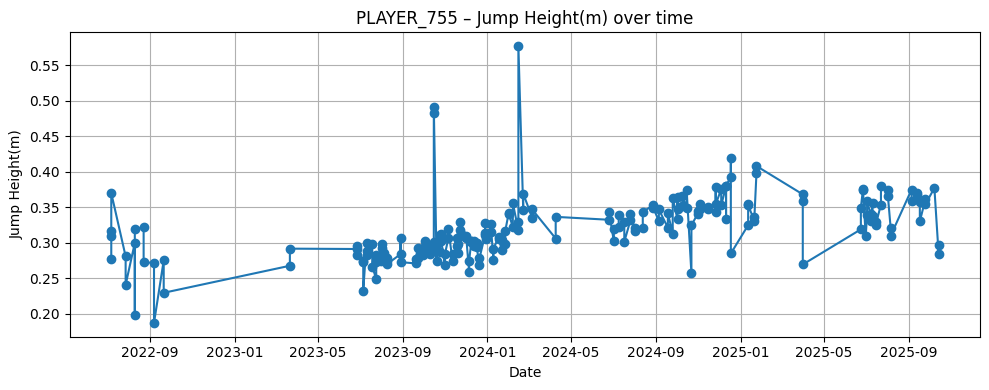


PLAYER_755 – Jump Height(m)
  BEST:  0.5771 on 2024-02-14
  WORST: 0.1872 on 2022-09-06

Trend for PLAYER_755 – Jump Height(m)
  Slope: 0.0001
  R: 0.543, p: 0.0000
  📈Interpretation: Improving over time

--- Peak Propulsive Force(N) ---


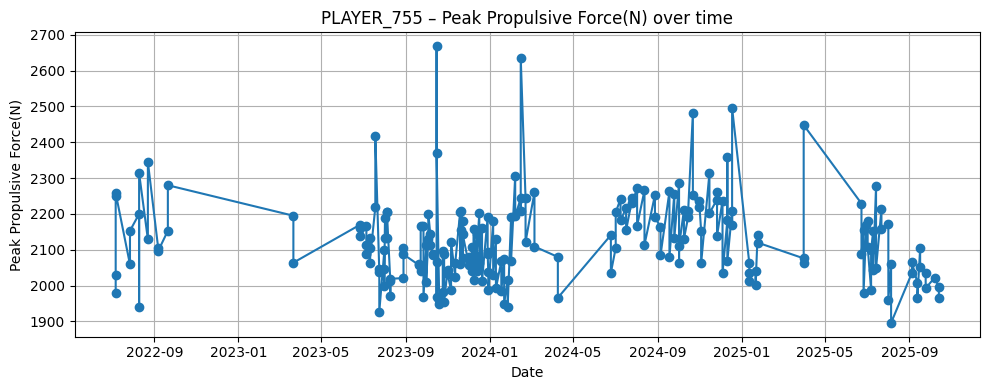


PLAYER_755 – Peak Propulsive Force(N)
  BEST:  2668.0 on 2023-10-15
  WORST: 1896.0 on 2025-08-05

Trend for PLAYER_755 – Peak Propulsive Force(N)
  Slope: -0.0041
  R: -0.011, p: 0.8787
  📉Interpretation: Declining over time

--- RSI ---


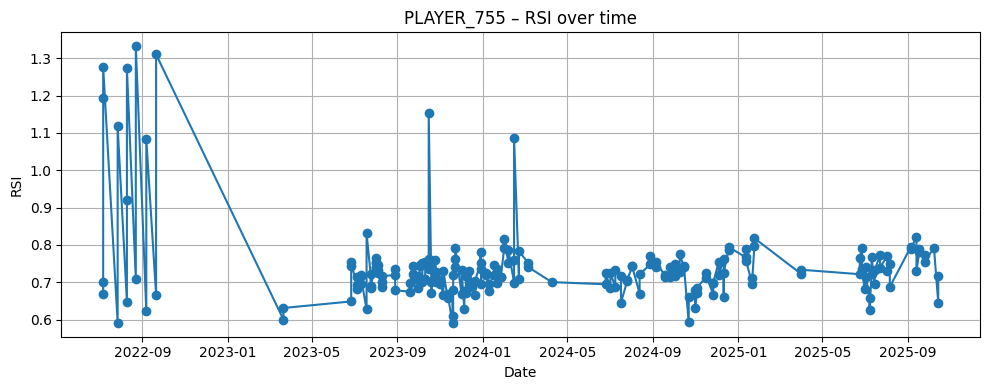


PLAYER_755 – RSI
  BEST:  1.3325 on 2022-08-22
  WORST: 0.5912 on 2023-11-18

Trend for PLAYER_755 – RSI
  Slope: -0.0001
  R: -0.226, p: 0.0010
  📉Interpretation: Declining over time

Analysis for PLAYER_1186 – Stony Brook Men's Basketball

--- accel_load_accum ---
No data for PLAYER_1186 – accel_load_accum
No data for PLAYER_1186 – accel_load_accum
Not enough data for trend: PLAYER_1186 – accel_load_accum

--- distance_total ---
No data for PLAYER_1186 – distance_total
No data for PLAYER_1186 – distance_total
Not enough data for trend: PLAYER_1186 – distance_total

--- Jump Height(m) ---


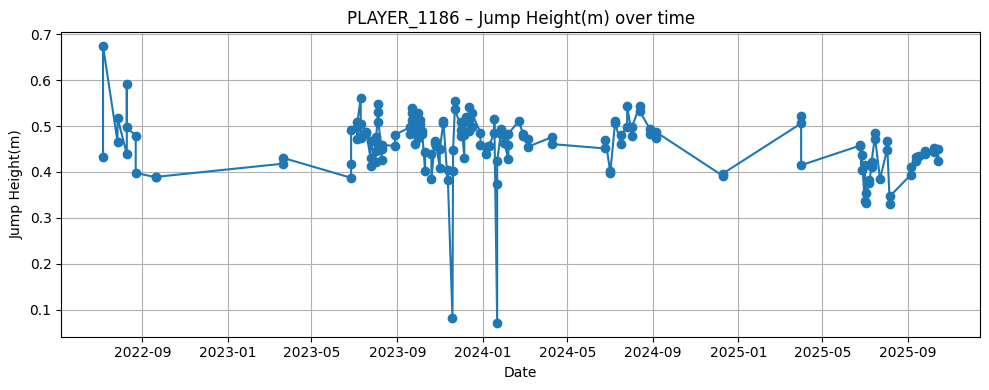


PLAYER_1186 – Jump Height(m)
  BEST:  0.6736 on 2022-07-06
  WORST: 0.0719 on 2024-01-21

Trend for PLAYER_1186 – Jump Height(m)
  Slope: -0.0001
  R: -0.262, p: 0.0006
  📉Interpretation: Declining over time

--- Peak Propulsive Force(N) ---


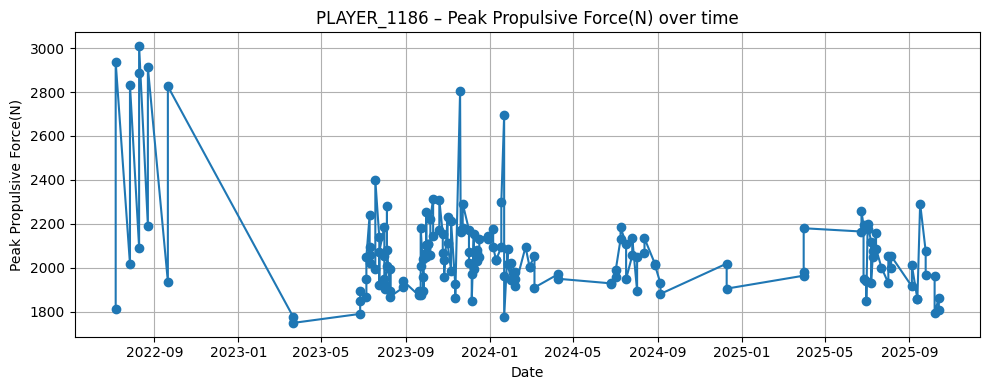


PLAYER_1186 – Peak Propulsive Force(N)
  BEST:  3009.0 on 2022-08-09
  WORST: 1749.0 on 2023-03-21

Trend for PLAYER_1186 – Peak Propulsive Force(N)
  Slope: -0.2171
  R: -0.303, p: 0.0001
  📉Interpretation: Declining over time

--- RSI ---


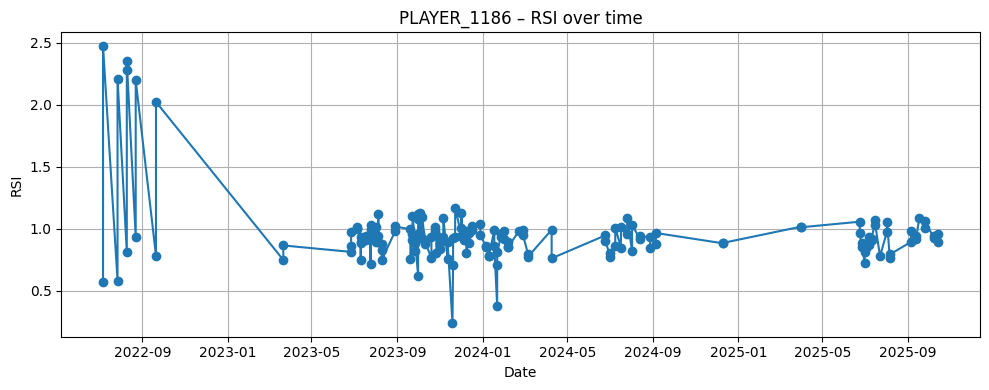


PLAYER_1186 – RSI
  BEST:  2.4731 on 2022-07-06
  WORST: 0.2388 on 2023-11-18

Trend for PLAYER_1186 – RSI
  Slope: -0.0003
  R: -0.269, p: 0.0005
  📉Interpretation: Declining over time


In [13]:
# Run full analysis for both athletes
for athlete in [athlete1, athlete2]:
    print("\n" + "="*60)
    print(f"Analysis for {athlete} – {TEAM_NAME}")
    print("="*60)

    for metric in selected_metrics:
        print(f"\n--- {metric} ---")
        
        # Plot
        _ = plot_metric_over_time(team_df, athlete, metric)
        
        # Best & Worst
        print_best_worst(team_df, athlete, metric)
        
        # Trend analysis
        trend_analysis(team_df, athlete, metric)

In [14]:
team_df["metric"].value_counts()

metric
Jump Height(m)              2999
Peak Propulsive Force(N)    2999
RSI                         2978
Name: count, dtype: int64

## Data Availability Note (Important)

#### Although our group selected five metrics (Jump Height, Peak Propulsive Force, RSI, Accumulated Acceleration Load, and Total Distance), only three of these metrics were available for the Men's Basketball athletes in this database.

Available Metrics (Hawkins Force Plates):

- Jump Height (m)

- Peak Propulsive Force (N)

- Reactive Strength Index (RSI)

#### These metrics are collected during indoor testing sessions using Hawkins force plates.

Missing Metrics (Kinexon GPS):

- Accumulated Acceleration Load

- Total Distance

#### These metrics require Kinexon GPS or LPS tracking systems, which are not typically used in indoor basketball settings and may not have been implemented during the data collection period.

Interpretation:

Because of this limitation, our Part 3.1 analysis focuses on:

- Performance changes in Jump Height, RSI, and Peak Propulsive Force

- Athlete trends over time using only force-plate-derived metrics

#### The absence of GPS-based workload metrics is a normal real-world limitation and demonstrates the challenges of working with incomplete multimodal performance datasets.